# PhishLens — Character-Level Deep Learning Model

A **character-level 1D-CNN** for phishing URL detection.  
Unlike the classical Random Forest baseline (which uses 9 hand-crafted lexical features),
this model operates directly on **raw URL text**, learning its own character-level
patterns — suspicious substrings, unusual character distributions, domain tricks —
end-to-end from the data.

**Architecture:**
```
URL chars → Embedding(32) → Conv1D(64, k=5) → GlobalMaxPool → Dense(64) → Dropout(0.3) → Dense(1, sigmoid)
```

**Dataset:** 11,430 URLs (50/50 phishing/legitimate), same as the baseline.

## 0. Setup & Imports

In [1]:
import json
import string
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

# Paths
ML_DIR = Path(".").resolve()
DATA_DIR = ML_DIR / "data"
MODELS_DIR = ML_DIR / "models"
RAW_CSV = DATA_DIR / "raw_urls.csv"

# Hyper-parameters
MAX_URL_LEN = 200      # pad/truncate all URLs to this length
EMBEDDING_DIM = 32     # character embedding dimensionality
CONV_FILTERS = 64      # number of 1D conv filters
KERNEL_SIZE = 5        # conv kernel width
DENSE_UNITS = 64       # hidden dense layer size
DROPOUT_RATE = 0.3     # dropout for regularization
BATCH_SIZE = 64
EPOCHS = 20
RANDOM_STATE = 42

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU available: False


## 1. Load Dataset

In [2]:
df = pd.read_csv(RAW_CSV)
print(f"Dataset: {len(df):,} rows")
print(f"Label distribution:\n{df['label'].value_counts().to_string()}")
print(f"\nSample URLs:")
for _, row in df.sample(5, random_state=RANDOM_STATE).iterrows():
    tag = "PHISH" if row['label'] == 1 else "LEGIT"
    print(f"  [{tag}] {row['url'][:80]}")

Dataset: 11,430 rows
Label distribution:
label
0    5715
1    5715

Sample URLs:
  [LEGIT] https://www.rga.com/about/workplace
  [LEGIT] http://starasia.com.hk
  [LEGIT] https://www.youtube.com/watch?v=XszqITK-UEw
  [LEGIT] http://www.civico1845.com/
  [PHISH] http://rapidpaws.com/wp-content/we_transfer/index2.php?email=/


## 2. Build Character Vocabulary

Scan every URL in the dataset and collect all unique printable ASCII characters.
Map each character to a unique integer index (1-indexed; 0 is reserved for padding).

In [3]:
# Collect all unique characters across the dataset
all_chars = set()
for url in df["url"]:
    all_chars.update(url)

# Keep only printable ASCII characters, sorted for reproducibility
printable_set = set(string.printable)
vocab_chars = sorted(ch for ch in all_chars if ch in printable_set)

# Build char -> index mapping (1-indexed; 0 = padding)
char_to_idx = {ch: idx + 1 for idx, ch in enumerate(vocab_chars)}
vocab_size = len(char_to_idx) + 1  # +1 for the padding index 0

print(f"Vocabulary size: {vocab_size} (including padding token)")
print(f"Characters: {''.join(vocab_chars[:50])}{'...' if len(vocab_chars) > 50 else ''}")

# Save vocabulary for inference
MODELS_DIR.mkdir(parents=True, exist_ok=True)
vocab_path = MODELS_DIR / "char_vocab.json"
with open(vocab_path, "w") as f:
    json.dump({
        "char_to_idx": char_to_idx,
        "max_url_len": MAX_URL_LEN,
        "vocab_size": vocab_size,
    }, f, indent=2)
print(f"Saved vocabulary to: {vocab_path}")

Vocabulary size: 92 (including padding token)
Characters:  !#$%&'()*+,-./0123456789:;<=?@ABCDEFGHIJKLMNOPQRS...
Saved vocabulary to: /Users/khushi22/Phishlens/PhishLens/ml/models/char_vocab.json


## 3. Encode URLs as Integer Sequences

Each URL is converted to a fixed-length sequence of character indices:
- Characters not in the vocabulary are mapped to 0 (treated as padding)
- URLs shorter than `MAX_URL_LEN` are right-padded with 0s
- URLs longer than `MAX_URL_LEN` are truncated

In [4]:
def encode_url(url: str, char_map: dict, max_len: int) -> np.ndarray:
    """Encode a single URL string into a fixed-length integer array."""
    encoded = [char_map.get(ch, 0) for ch in url[:max_len]]
    # Pad with 0s if shorter than max_len
    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    return np.array(encoded, dtype=np.int32)


# Encode the full dataset
X = np.array([encode_url(url, char_to_idx, MAX_URL_LEN) for url in df["url"]])
y = df["label"].values.astype(np.float32)

print(f"X shape: {X.shape}  (samples × max_url_len)")
print(f"y shape: {y.shape}")
print(f"\nExample encoded URL (first 30 chars):")
print(f"  URL:     {df['url'].iloc[0][:30]}")
print(f"  Encoded: {X[0][:30]}")

X shape: (11430, 200)  (samples × max_url_len)
y shape: (11430,)

Example encoded URL (first 30 chars):
  URL:     http://www.crestonwood.com/rou
  Encoded: [70 82 82 78 26 15 15 85 85 85 14 65 80 67 81 82 77 76 85 77 77 66 14 65
 77 75 15 80 77 83]


## 4. Train/Test Split (80/20 Stratified)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train):,} samples")
print(f"Test:  {len(X_test):,} samples")
print(f"Train label distribution: {np.bincount(y_train.astype(int))}")
print(f"Test  label distribution: {np.bincount(y_test.astype(int))}")

Train: 9,144 samples
Test:  2,286 samples
Train label distribution: [4572 4572]
Test  label distribution: [1143 1143]


## 5. Build the Character-Level CNN Model

Architecture:
1. **Embedding** — maps each character index to a dense 32-dim vector
2. **Conv1D** — 64 filters, kernel size 5, detects local character n-gram patterns
3. **GlobalMaxPooling1D** — extracts the strongest activation per filter
4. **Dense(64, relu)** — learns non-linear feature combinations
5. **Dropout(0.3)** — regularization to prevent overfitting
6. **Dense(1, sigmoid)** — binary output (phishing probability)

In [6]:
def build_char_cnn(vocab_size: int, max_len: int) -> keras.Model:
    """Build a character-level 1D-CNN for URL classification."""
    model = keras.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            mask_zero=False,
            name="char_embedding",
        ),
        layers.Conv1D(
            filters=CONV_FILTERS,
            kernel_size=KERNEL_SIZE,
            activation="relu",
            padding="same",
            name="conv1d",
        ),
        layers.GlobalMaxPooling1D(name="global_max_pool"),
        layers.Dense(DENSE_UNITS, activation="relu", name="dense_hidden"),
        layers.Dropout(DROPOUT_RATE, name="dropout"),
        layers.Dense(1, activation="sigmoid", name="output"),
    ])
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_char_cnn(vocab_size, MAX_URL_LEN)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ char_embedding (Embedding)      │ (None, 200, 32)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train with Early Stopping

In [7]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train, y_train,
    validation_split=0.15,    # 15% of training data for validation
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/20


  1/122 ━━━━━━━━━━━━━━━━━━━━ 1:21 671ms/step - accuracy: 0.3594 - loss: 0.6959

 10/122 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4768 - loss: 0.6926    

 19/122 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5284 - loss: 0.6901

 28/122 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5601 - loss: 0.6869

...

114/122 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9693 - loss: 0.0931

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9692 - loss: 0.0933

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9680 - loss: 0.0958 - val_accuracy: 0.9184 - val_loss: 0.2111


Epoch 10: early stopping


Restoring model weights from the end of the best epoch: 7.


## 7. Training History Visualization

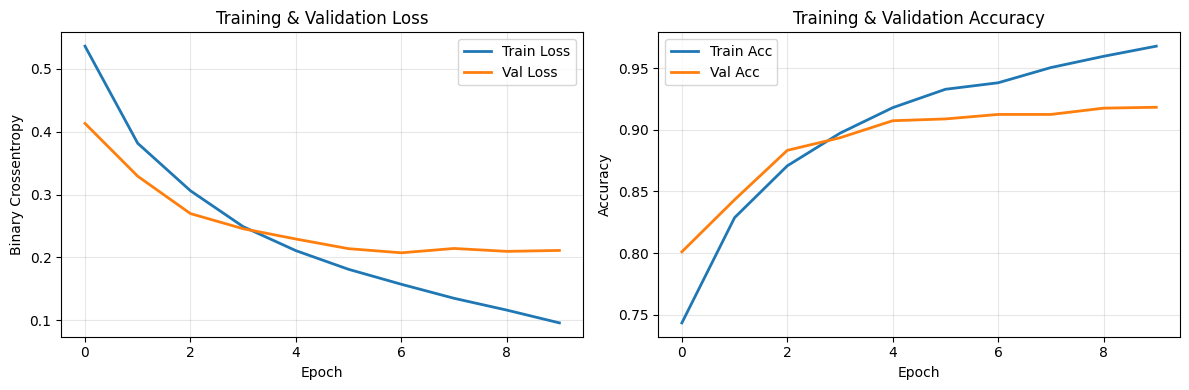


Best epoch: 7
Best val_loss: 0.2074
Best val_accuracy: 0.9184


In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(history.history["loss"], label="Train Loss", linewidth=2)
ax1.plot(history.history["val_loss"], label="Val Loss", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Binary Crossentropy")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history.history["accuracy"], label="Train Acc", linewidth=2)
ax2.plot(history.history["val_accuracy"], label="Val Acc", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training & Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = early_stopping.stopped_epoch - early_stopping.patience + 1 if early_stopping.stopped_epoch > 0 else len(history.history['loss'])
print(f"\nBest epoch: {best_epoch}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

## 8. Evaluate on Test Set

In [9]:
def false_positive_rate(y_true, y_pred):
    """FPR = FP / (FP + TN)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0


# Get predictions
y_proba = model.predict(X_test, batch_size=BATCH_SIZE).flatten()
y_pred = (y_proba >= 0.5).astype(int)

# Compute metrics
deep_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "FPR": false_positive_rate(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

print("Deep Learning Model — Test Set Results")
print("=" * 45)
for metric, value in deep_metrics.items():
    print(f"  {metric:<12} {value:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"  TN={cm[0,0]:>5}  FP={cm[0,1]:>5}")
print(f"  FN={cm[1,0]:>5}  TP={cm[1,1]:>5}")

 1/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

26/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Deep Learning Model — Test Set Results
  Accuracy     0.9226
  Precision    0.9290
  Recall       0.9151
  F1-Score     0.9220
  FPR          0.0700
  ROC-AUC      0.9739

Confusion Matrix:
  TN= 1063  FP=   80
  FN=   97  TP= 1046


## 9. Comparison: Deep Learning vs. Classical Baseline

Load the baseline Random Forest metrics from `baseline_metadata.json` and print
a side-by-side comparison table.

In [10]:
# Load baseline metrics
baseline_meta_path = MODELS_DIR / "baseline_metadata.json"
with open(baseline_meta_path) as f:
    baseline_meta = json.load(f)

baseline_metrics = baseline_meta["metrics"]

# Print comparison table
print("=" * 80)
print("  MODEL COMPARISON — Classical Baseline vs. Deep Learning")
print("  Dataset: 11,430 URLs (50/50 phishing/legit) | Split: 80/20 stratified")
print("=" * 80)
print()
print(f"  {'Approach':<28} {'Features':<30}")
print(f"  {'Random Forest (Baseline)':<28} {'9 hand-crafted lexical':<30}")
print(f"  {'Char-CNN (Deep Learning)':<28} {'Raw URL characters (200 max)':<30}")
print()

header = f"  {'Metric':<14} {'RF Baseline':>12} {'Char-CNN':>12} {'Δ':>10}"
print(header)
print("  " + "-" * 50)

for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "FPR", "ROC-AUC"]:
    bl = baseline_metrics.get(metric, 0)
    dl = deep_metrics.get(metric, 0)
    delta = dl - bl
    # For FPR, lower is better, so flip the indicator
    if metric == "FPR":
        indicator = "✓" if delta < 0 else "✗" if delta > 0 else "="
    else:
        indicator = "✓" if delta > 0 else "✗" if delta < 0 else "="
    print(f"  {metric:<14} {bl:>12.4f} {dl:>12.4f} {delta:>+9.4f} {indicator}")

print("  " + "-" * 50)
print()

# Highlight winner per F1
bl_f1 = baseline_metrics.get("F1-Score", 0)
dl_f1 = deep_metrics.get("F1-Score", 0)
if dl_f1 > bl_f1:
    print(f"  ★ Deep Learning model WINS by F1-Score: {dl_f1:.4f} vs {bl_f1:.4f} (+{dl_f1-bl_f1:.4f})")
elif dl_f1 < bl_f1:
    print(f"  ★ Baseline model still leads by F1-Score: {bl_f1:.4f} vs {dl_f1:.4f}")
    print(f"    (Deep model is a complementary technique, not a replacement)")
else:
    print(f"  ★ Models are tied on F1-Score: {dl_f1:.4f}")

print()
print("  Key insight: These models use ENTIRELY DIFFERENT features.")
print("  The baseline uses hand-crafted lexical statistics.")
print("  The deep model learns directly from raw character sequences.")
print("  Ensembling them can capture complementary patterns.")
print("=" * 80)

  MODEL COMPARISON — Classical Baseline vs. Deep Learning
  Dataset: 11,430 URLs (50/50 phishing/legit) | Split: 80/20 stratified

  Approach                     Features                      
  Random Forest (Baseline)     9 hand-crafted lexical        
  Char-CNN (Deep Learning)     Raw URL characters (200 max)  

  Metric          RF Baseline     Char-CNN          Δ
  --------------------------------------------------
  Accuracy             0.8097       0.9226   +0.1129 ✓
  Precision            0.8327       0.9290   +0.0963 ✓
  Recall               0.7752       0.9151   +0.1399 ✓
  F1-Score             0.8029       0.9220   +0.1191 ✓
  FPR                  0.1557       0.0700   -0.0857 ✓
  ROC-AUC              0.8889       0.9739   +0.0850 ✓
  --------------------------------------------------

  ★ Deep Learning model WINS by F1-Score: 0.9220 vs 0.8029 (+0.1191)

  Key insight: These models use ENTIRELY DIFFERENT features.
  The baseline uses hand-crafted lexical statistics.
  The d

## 10. Save Model & Metadata

In [11]:
# Save the trained model
model_path = MODELS_DIR / "deep_model.h5"
model.save(model_path)
print(f"Saved model to: {model_path}")

# Save deep model metadata
deep_metadata = {
    "model_name": "Character-Level CNN",
    "model_type": "deep-learning-char-cnn",
    "description": (
        "Character-level 1D-CNN trained directly on raw URL text. "
        "No hand-crafted features — the model learns character-level patterns "
        "(suspicious substrings, domain tricks, etc.) end-to-end from data."
    ),
    "architecture": {
        "input": f"URL encoded as {MAX_URL_LEN}-length integer sequence",
        "layers": [
            f"Embedding(vocab_size={vocab_size}, dim={EMBEDDING_DIM})",
            f"Conv1D(filters={CONV_FILTERS}, kernel_size={KERNEL_SIZE}, relu)",
            "GlobalMaxPooling1D",
            f"Dense({DENSE_UNITS}, relu)",
            f"Dropout({DROPOUT_RATE})",
            "Dense(1, sigmoid)",
        ],
    },
    "training": {
        "optimizer": "adam",
        "loss": "binary_crossentropy",
        "epochs_trained": len(history.history["loss"]),
        "max_epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "early_stopping_patience": 3,
        "validation_split": 0.15,
    },
    "vocab": {
        "vocab_size": vocab_size,
        "max_url_len": MAX_URL_LEN,
        "file": "char_vocab.json",
    },
    "label_encoding": {"legitimate": 0, "phishing": 1},
    "dataset_size": len(df),
    "train_size": len(X_train),
    "test_size": len(X_test),
    "metrics": {k: round(v, 4) for k, v in deep_metrics.items()},
    "baseline_comparison": {
        "baseline_model": baseline_meta["model_name"],
        "baseline_metrics": {k: round(v, 4) if isinstance(v, float) else v
                            for k, v in baseline_metrics.items()},
    },
    "files": {
        "model": "deep_model.h5",
        "vocabulary": "char_vocab.json",
        "metadata": "deep_metadata.json",
    },
}

deep_meta_path = MODELS_DIR / "deep_metadata.json"
with open(deep_meta_path, "w") as f:
    json.dump(deep_metadata, f, indent=2)
print(f"Saved metadata to: {deep_meta_path}")

Saved model to: /Users/khushi22/Phishlens/PhishLens/ml/models/deep_model.h5
Saved metadata to: /Users/khushi22/Phishlens/PhishLens/ml/models/deep_metadata.json


## 11. Quick Inference Test

Run the saved model on a few sample URLs to verify it works end-to-end.

In [12]:
# Reload model and vocab to simulate fresh inference
loaded_model = keras.models.load_model(model_path)

with open(vocab_path) as f:
    loaded_vocab = json.load(f)
loaded_char_map = loaded_vocab["char_to_idx"]
loaded_max_len = loaded_vocab["max_url_len"]

test_urls = [
    ("https://www.google.com", "should be legit"),
    ("http://mybank-login-secure.verify-account.com", "should be phishing"),
    ("https://xn--pple-43d.com", "punycode, should be phishing"),
    ("https://github.com/tensorflow/tensorflow", "should be legit"),
    ("http://secure-paypal-login.com/update?id=12345", "should be phishing"),
]

print("Quick Inference Test — Character-Level CNN")
print("=" * 85)
for url, expected in test_urls:
    encoded = encode_url(url, loaded_char_map, loaded_max_len)
    encoded_batch = np.expand_dims(encoded, axis=0)  # add batch dim
    prob = loaded_model.predict(encoded_batch, verbose=0)[0, 0]
    verdict = "PHISHING" if prob >= 0.5 else "LEGIT"
    print(f"  {url:<55} → {verdict:<10} (conf: {max(prob, 1-prob):.2%})  [{expected}]")
print("=" * 85)

Quick Inference Test — Character-Level CNN


  https://www.google.com                                  → LEGIT      (conf: 99.05%)  [should be legit]


  http://mybank-login-secure.verify-account.com           → PHISHING   (conf: 99.26%)  [should be phishing]
  https://xn--pple-43d.com                                → LEGIT      (conf: 90.08%)  [punycode, should be phishing]


  https://github.com/tensorflow/tensorflow                → LEGIT      (conf: 75.59%)  [should be legit]


  http://secure-paypal-login.com/update?id=12345          → PHISHING   (conf: 99.55%)  [should be phishing]


## 12. Summary

| Aspect | Baseline (Random Forest) | Deep Model (Char-CNN) |
|--------|--------------------------|----------------------|
| **Input** | 9 hand-crafted lexical features | Raw URL characters (200 max) |
| **Technique** | Classical ML (tree ensemble) | Deep Learning (1D-CNN) |
| **Feature Engineering** | Manual (entropy, dot count, etc.) | Learned end-to-end |
| **Strengths** | Fast, interpretable, works on known patterns | Can discover novel character-level patterns |
| **Weaknesses** | Limited to pre-defined features | Needs more data to shine, less interpretable |
| **Complementary?** | ✓ Yes — different feature spaces mean ensembling captures more signal |

Both models are now saved and can be loaded by the backend inference engine.